In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

df = pd.read_csv(r"C:\Users\USER\Downloads\apple_quality.csv")
df.head()

,A_id,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity,Quality
0,0.0,-3.970049,-2.512336,5.346330,-1.012009,1.844900,0.329840,-0.491590483,good
1,1.0,-1.195217,-2.839257,3.664059,1.588232,0.853286,0.867530,-0.722809367,good
2,2.0,-0.292024,-1.351282,-1.738429,-0.342616,2.838636,-0.038033,2.621636473,bad
3,3.0,-0.657196,-2.271627,1.324874,-0.097875,3.637970,-3.413761,0.790723217,good
4,4.0,1.364217,-1.296612,-0.384658,-0.553006,3.030874,-1.303849,0.501984036,good


In [2]:
df = df.drop(columns=["A_id"],  errors="ignore")
df["Acidity"] = pd.to_numeric(df["Acidity"], errors="coerce")
df = df.dropna()
df.info(), df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Size         4000 non-null   float64
 1   Weight       4000 non-null   float64
 2   Sweetness    4000 non-null   float64
 3   Crunchiness  4000 non-null   float64
 4   Juiciness    4000 non-null   float64
 5   Ripeness     4000 non-null   float64
 6   Acidity      4000 non-null   float64
 7   Quality      4000 non-null   object 
dtypes: float64(7), object(1)
memory usage: 281.2+ KB


(None,
        Size    Weight  Sweetness  Crunchiness  Juiciness  Ripeness   Acidity  \
 0 -3.970049 -2.512336   5.346330    -1.012009   1.844900  0.329840 -0.491590   
 1 -1.195217 -2.839257   3.664059     1.588232   0.853286  0.867530 -0.722809   
 2 -0.292024 -1.351282  -1.738429    -0.342616   2.838636 -0.038033  2.621636   
 3 -0.657196 -2.271627   1.324874    -0.097875   3.637970 -3.413761  0.790723   
 4  1.364217 -1.296612  -0.384658    -0.553006   3.030874 -1.303849  0.501984   
 
   Quality  
 0    good  
 1    good  
 2     bad  
 3    good  
 4    good  )

Class distribution:
Quality
good    2004
bad     1996
Name: count, dtype: int64

Balance ratio: 0.996 (1.0 = perfectly balanced)


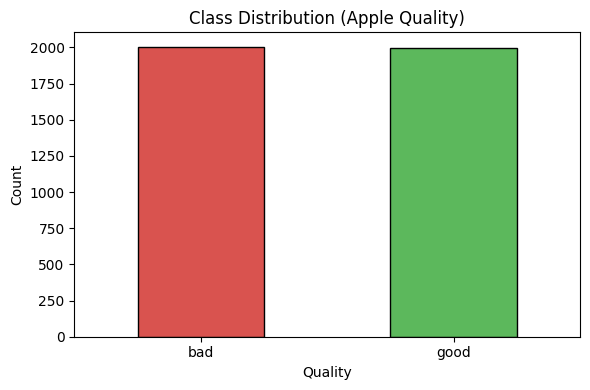

In [3]:
# Class balance check
class_counts = df["Quality"].value_counts()
print("Class distribution:")
print(class_counts)
print(f"\nBalance ratio: {class_counts.min() / class_counts.max():.3f} (1.0 = perfectly balanced)")

class_counts.plot.bar(figsize=(6, 4), color=["#d9534f", "#5cb85c"], edgecolor="black")
plt.title("Class Distribution (Apple Quality)")
plt.xlabel("Quality")
plt.ylabel("Count")
plt.xticks(ticks=[0, 1], labels=["bad", "good"], rotation=0)
plt.tight_layout()
plt.show()

In [4]:
X = df.drop(columns=["Quality"])
y = df["Quality"].map({"good": 1, "bad": 0})


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")


Training set size: 3200 samples
Testing set size: 800 samples


In [5]:
#Logistic Regression pipeline
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(C=0.1, max_iter=1000, random_state=42))
])

pipe_lr.fit(X_train, y_train)
y_pred_lr = pipe_lr.predict(X_test)

In [6]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)
roc_lr = roc_auc_score(y_test, pipe_lr.predict_proba(X_test)[:, 1])
print(f"Accuracy (Logistic Regression): {accuracy_lr:.2f}")
print(f"ROC-AUC (Logistic Regression): {roc_lr:.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))

Accuracy (Logistic Regression): 0.75
ROC-AUC (Logistic Regression): 0.81

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.72      0.74       399
           1       0.73      0.78      0.76       401

    accuracy                           0.75       800
   macro avg       0.75      0.75      0.75       800
weighted avg       0.75      0.75      0.75       800

Confusion Matrix:
 [[286 113]
 [ 89 312]]


In [7]:
pipe_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(random_state=42))
])

param_grid_rf = {
    'clf__n_estimators': [100, 200],
    'clf__max_depth': [None, 10, 20],
    'clf__min_samples_split': [2, 5]
}

gs_rf = GridSearchCV(pipe_rf, param_grid_rf, cv=5, scoring='accuracy', n_jobs=-1)
gs_rf.fit(X_train, y_train)

print(f"Best RF params: {gs_rf.best_params_}")
print(f"Best CV Accuracy: {gs_rf.best_score_:.2f}")

y_pred_rf = gs_rf.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
roc_rf = roc_auc_score(y_test, gs_rf.predict_proba(X_test)[:, 1])
print(f"\nTest Accuracy (Random Forest): {accuracy_rf:.2f}")
print(f"ROC-AUC (Random Forest): {roc_rf:.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Best RF params: {'clf__max_depth': None, 'clf__min_samples_split': 2, 'clf__n_estimators': 200}
Best CV Accuracy: 0.89

Test Accuracy (Random Forest): 0.88
ROC-AUC (Random Forest): 0.95

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.84      0.87       399
           1       0.85      0.92      0.88       401

    accuracy                           0.88       800
   macro avg       0.88      0.88      0.88       800
weighted avg       0.88      0.88      0.88       800

Confusion Matrix:
 [[334  65]
 [ 33 368]]


In [8]:
pipe_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(kernel='rbf', random_state=42, probability=True))
])

param_grid_svm = {
    'clf__C': [0.1, 1, 10, 100],
    'clf__gamma': ['scale', 'auto', 0.01, 0.001]
}

gs_svm = GridSearchCV(pipe_svm, param_grid_svm, cv=5, scoring='accuracy', n_jobs=-1)
gs_svm.fit(X_train, y_train)

print(f"Best SVM params: {gs_svm.best_params_}")
print(f"Best CV Accuracy: {gs_svm.best_score_:.2f}")

y_pred_svm = gs_svm.predict(X_test)
accuracy_svm = accuracy_score(y_test, y_pred_svm)
roc_svm = roc_auc_score(y_test, gs_svm.predict_proba(X_test)[:, 1])
print(f"\nTest Accuracy (SVM): {accuracy_svm:.2f}")
print(f"ROC-AUC (SVM): {roc_svm:.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))

Best SVM params: {'clf__C': 100, 'clf__gamma': 'scale'}
Best CV Accuracy: 0.91

Test Accuracy (SVM): 0.91
ROC-AUC (SVM): 0.97

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.91      0.91       399
           1       0.91      0.91      0.91       401

    accuracy                           0.91       800
   macro avg       0.91      0.91      0.91       800
weighted avg       0.91      0.91      0.91       800

Confusion Matrix:
 [[363  36]
 [ 36 365]]


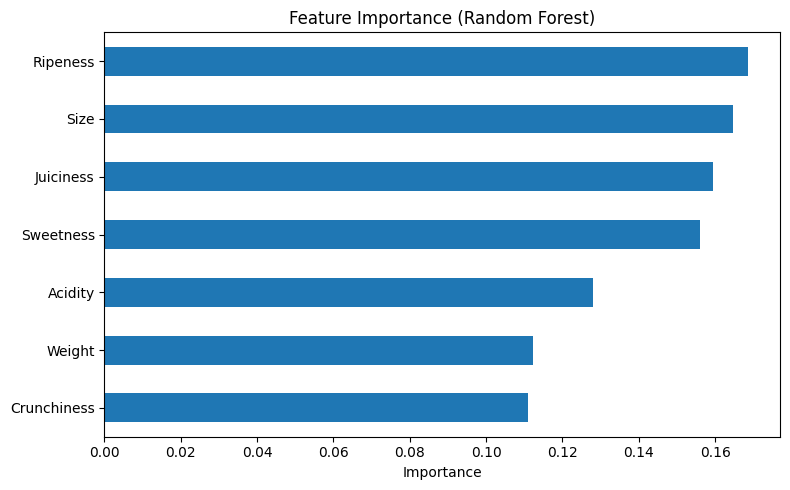

In [9]:
# Feature importance from the best Random Forest
best_rf = gs_rf.best_estimator_.named_steps['clf']
importances = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values()

importances.plot.barh(figsize=(8, 5))
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [10]:
# Cross-validation comparison across all three models
models = {
    'Logistic Regression': pipe_lr,
    'Random Forest': gs_rf.best_estimator_,
    'SVM': gs_svm.best_estimator_,
}

print(f"{'Model':<25} {'CV Accuracy (meanÂ±std)'}")
print("-" * 50)
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    print(f"{name:<25} {scores.mean():.3f} Â± {scores.std():.3f}")

Model                     CV Accuracy (meanÂ±std)
--------------------------------------------------
Logistic Regression       0.747 Â± 0.020


Random Forest             0.887 Â± 0.015


SVM                       0.909 Â± 0.010


In [11]:
# XGBoost with StratifiedKFold GridSearchCV — Thakur book: always stratify CV for classification,
# and use ROC-AUC (not accuracy) as the tuning metric
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pipe_xgb = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    XGBClassifier(random_state=42, verbosity=0, eval_metric='logloss'))
])

param_grid_xgb = {
    'clf__n_estimators':  [100, 200],
    'clf__max_depth':     [3, 6],
    'clf__learning_rate': [0.1, 0.3],
    'clf__subsample':     [0.8, 1.0],
}

gs_xgb = GridSearchCV(pipe_xgb, param_grid_xgb, cv=skf, scoring='roc_auc', n_jobs=-1)
gs_xgb.fit(X_train, y_train)

print(f"Best XGBoost params: {gs_xgb.best_params_}")
print(f"Best CV ROC-AUC:     {gs_xgb.best_score_:.4f}")

y_pred_xgb    = gs_xgb.predict(X_test)
accuracy_xgb  = accuracy_score(y_test, y_pred_xgb)
roc_xgb       = roc_auc_score(y_test, gs_xgb.predict_proba(X_test)[:, 1])
print(f"\nTest Accuracy (XGBoost): {accuracy_xgb:.2f}")
print(f"ROC-AUC   (XGBoost): {roc_xgb:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))

Best XGBoost params: {'clf__learning_rate': 0.1, 'clf__max_depth': 6, 'clf__n_estimators': 200, 'clf__subsample': 0.8}
Best CV ROC-AUC:     0.9573

Test Accuracy (XGBoost): 0.87
ROC-AUC   (XGBoost): 0.9502

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.86      0.87       399
           1       0.86      0.89      0.87       401

    accuracy                           0.87       800
   macro avg       0.87      0.87      0.87       800
weighted avg       0.87      0.87      0.87       800

Confusion Matrix:
 [[342  57]
 [ 45 356]]


In [12]:
# Polynomial Features (degree-2) + SVM — Thakur book: feature engineering is often the biggest lever
# degree=2 creates all pairwise interactions: e.g. Sweetness*Acidity, Size*Weight, etc.
pipe_poly_svm = Pipeline([
    ('poly',   PolynomialFeatures(degree=2, interaction_only=False, include_bias=False)),
    ('scaler', StandardScaler()),
    ('clf',    SVC(kernel='rbf', C=100, gamma='scale', random_state=42, probability=True))
])

pipe_poly_svm.fit(X_train, y_train)
y_pred_poly    = pipe_poly_svm.predict(X_test)
accuracy_poly  = accuracy_score(y_test, y_pred_poly)
roc_poly       = roc_auc_score(y_test, pipe_poly_svm.predict_proba(X_test)[:, 1])

n_orig  = X_train.shape[1]
n_poly  = pipe_poly_svm.named_steps['poly'].transform(X_train).shape[1]
print(f"Features: {n_orig} original  →  {n_poly} after degree-2 polynomial")
print(f"\nTest Accuracy (SVM + Poly): {accuracy_poly:.2f}")
print(f"ROC-AUC   (SVM + Poly): {roc_poly:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_poly))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_poly))

Features: 7 original  →  35 after degree-2 polynomial

Test Accuracy (SVM + Poly): 0.89
ROC-AUC   (SVM + Poly): 0.9569

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.89      0.89       399
           1       0.89      0.89      0.89       401

    accuracy                           0.89       800
   macro avg       0.89      0.89      0.89       800
weighted avg       0.89      0.89      0.89       800

Confusion Matrix:
 [[357  42]
 [ 45 356]]


In [13]:
# Out-of-Fold (OOF) ROC-AUC — Thakur book ch.2: OOF on the full training set is the gold standard
# for comparing models without touching the test set
def oof_roc_auc(model, X, y, cv):
    oof_preds = np.zeros(len(y))
    for train_idx, val_idx in cv.split(X, y):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr = y.iloc[train_idx]
        model.fit(X_tr, y_tr)
        oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]
    return roc_auc_score(y, oof_preds)

skf_oof = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_models = {
    'Logistic Regression': pipe_lr,
    'Random Forest':       gs_rf.best_estimator_,
    'SVM':                 gs_svm.best_estimator_,
    'XGBoost':             gs_xgb.best_estimator_,
    'SVM + Poly Features': pipe_poly_svm,
}

print("Out-of-Fold ROC-AUC (StratifiedKFold n=5):")
print("-" * 45)
for name, model in oof_models.items():
    score = oof_roc_auc(model, X_train, y_train, skf_oof)
    print(f"  {name:<25} {score:.4f}")

Out-of-Fold ROC-AUC (StratifiedKFold n=5):
---------------------------------------------
  Logistic Regression       0.8258


  Random Forest             0.9530


  SVM                       0.9625


  XGBoost                   0.9577


  SVM + Poly Features       0.9540


In [14]:
# Soft-voting ensemble — Thakur book ch.6: averaging uncorrelated model probabilities reduces variance
proba_lr   = pipe_lr.predict_proba(X_test)[:, 1]
proba_rf   = gs_rf.predict_proba(X_test)[:, 1]
proba_svm  = gs_svm.predict_proba(X_test)[:, 1]
proba_xgb  = gs_xgb.predict_proba(X_test)[:, 1]
proba_poly = pipe_poly_svm.predict_proba(X_test)[:, 1]

proba_ensemble = (proba_lr + proba_rf + proba_svm + proba_xgb + proba_poly) / 5
y_pred_ensemble = (proba_ensemble >= 0.5).astype(int)

accuracy_ensemble = accuracy_score(y_test, y_pred_ensemble)
roc_ensemble = roc_auc_score(y_test, proba_ensemble)
print(f"Test Accuracy (Ensemble avg): {accuracy_ensemble:.2f}")
print(f"ROC-AUC   (Ensemble avg): {roc_ensemble:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_ensemble))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_ensemble))

Test Accuracy (Ensemble avg): 0.89
ROC-AUC   (Ensemble avg): 0.9601

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.89      0.89       399
           1       0.90      0.89      0.89       401

    accuracy                           0.89       800
   macro avg       0.89      0.89      0.89       800
weighted avg       0.89      0.89      0.89       800

Confusion Matrix:
 [[357  42]
 [ 43 358]]


In [15]:
# Final model comparison — all models ranked by ROC-AUC
results = [
    ('Logistic Regression',  accuracy_lr,        roc_lr),
    ('Random Forest',        accuracy_rf,        roc_rf),
    ('SVM',                  accuracy_svm,       roc_svm),
    ('XGBoost',              accuracy_xgb,       roc_xgb),
    ('SVM + Poly Features',  accuracy_poly,      roc_poly),
    ('Ensemble (avg)',        accuracy_ensemble,  roc_ensemble),
]

print(f"{'Model':<25} {'Accuracy':>10} {'ROC-AUC':>10}")
print("=" * 48)
for name, acc, roc in sorted(results, key=lambda x: x[2], reverse=True):
    print(f"{name:<25} {acc:>10.3f} {roc:>10.3f}")

Model                       Accuracy    ROC-AUC
SVM                            0.910      0.965
Ensemble (avg)                 0.894      0.960
SVM + Poly Features            0.891      0.957
Random Forest                  0.877      0.950
XGBoost                        0.873      0.950
Logistic Regression            0.748      0.812
